# Clustering

* https://towardsdatascience.com/k-means-clustering-and-principal-component-analysis-in-10-minutes-2c5b69c36b6b
* https://medium.com/mlearning-ai/the-only-3-python-cheatsheet-you-need-as-a-beginner-data-scientist-7547cf70f3c1

# Supervised / Unsupervised / Semi Supervised (Self-Training) Learning

Labels or no labels

Unsupervised learning is a type of algorithm that learns patterns from untagged data. The hope is that through mimicry, which is an important mode of learning in people, the machine is forced to build a compact internal representation of its world and then generate imaginative content from it. In contrast to supervised learning where data is tagged by an expert, e.g. as a "ball" or "fish", unsupervised methods exhibit self-organization that captures patterns as probability densities or a combination of neural feature preferences. The other levels in the supervision spectrum are reinforcement learning where the machine is given only a numerical performance score as guidance, and semi-supervised learning where a smaller portion of the data is tagged. 

https://en.wikipedia.org/wiki/Unsupervised_learning

### Sklearn Examples

* Supervised - model.fit(X_train, y_train)
* Unsupervised - model.fit(X_train)

### Why Unsupervised Learning?

* Underlying Patterns
* Hidden Structures
* Latent Variables

### Applications of Unsupervised Learning

* Density Estimation
* Dimensionality Reduction

### Big O Runtime

https://www.freecodecamp.org/news/big-o-cheat-sheet-time-complexity-chart/

# Types of Clustering

Cluster analysis or clustering is the task of grouping a set of objects in such a way that objects in the same group (called a cluster) are more similar (in some sense) to each other than to those in other groups (clusters). It is a main task of exploratory data analysis, and a common technique for statistical data analysis, used in many fields, including pattern recognition, image analysis, information retrieval, bioinformatics, data compression, computer graphics and machine learning.

* K-Means
* Hierarchical Clustering
    * Agglomerative
    * Divisive
* Mean-Shift Clustering
* DBSCAN
* Expectation-Maximization (EM) Clustering using Gaussian Mixture Models (GMM)

https://en.wikipedia.org/wiki/Cluster_analysis

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


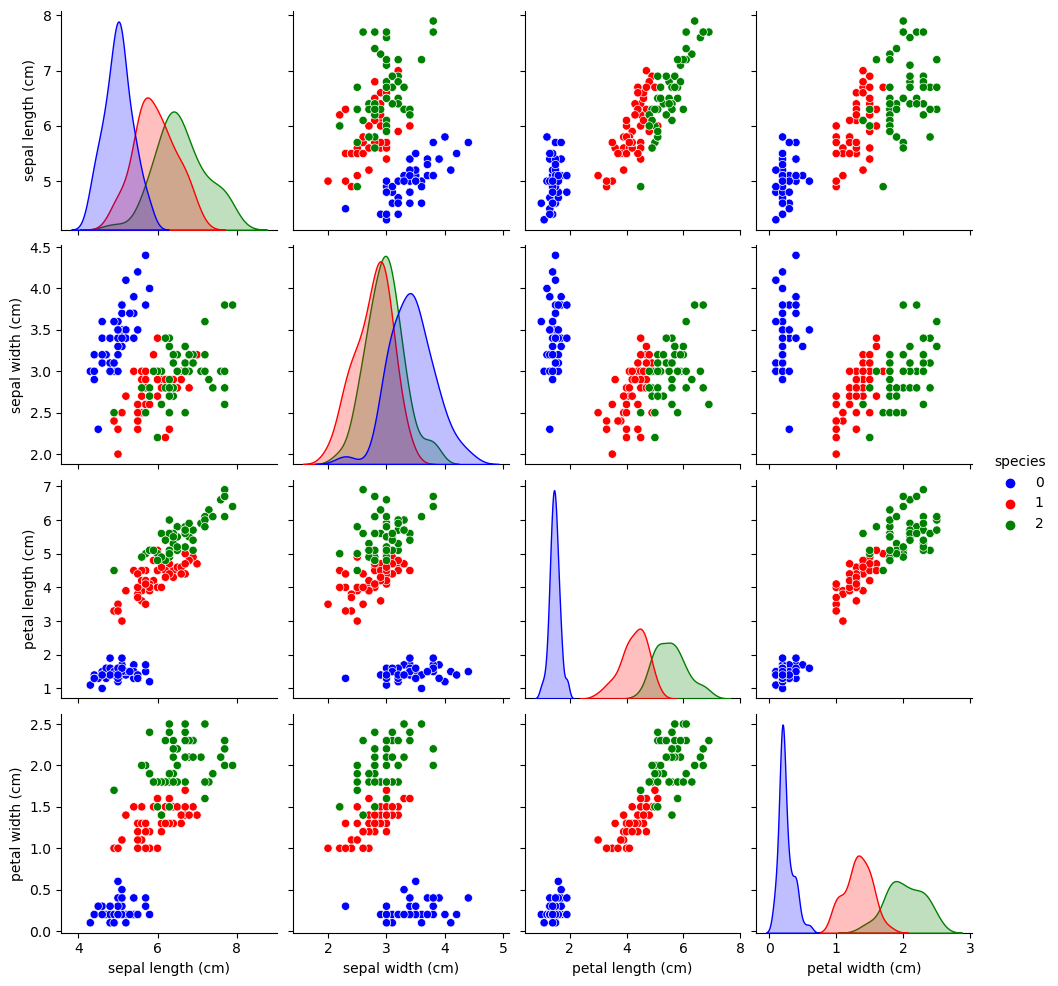

In [2]:
# pairplot visualization
import os
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

colors = ['blue', 'red', 'green']

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
print(df.head())

df['species'] = iris.target

sns.pairplot(df, hue='species', palette=colors)
plt.show()

## KMeans

KMeans requires knowing centroids. In mathematics and physics, the centroid or geometric center of a plane figure is the arithmetic mean position of all the points in the figure. Informally, it is the point at which a cutout of the shape could be perfectly balanced on the tip of a pin. The same definition extends to any object in n-dimensional space.

* https://en.wikipedia.org/wiki/Centroid
* https://en.wikipedia.org/wiki/K-means_clustering#/media/File:K-means_convergence.gif

### KMeans Process

* Choose the number of clusters (k) 
* Select random centroid for each cluster
* Assign all the points to the closest cluster centroid
* Recompute centroids of newly formed clusters
* Repeat steps 3 and 4 until centroids no longer change

https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/

<img src='https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif' alt='kmeans convergence' />

By Chire - Own work, CC BY-SA 4.0, https://commons.wikimedia.org/w/index.php?curid=59409335

### Readings:

* https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
* https://towardsdatascience.com/the-5-clustering-algorithms-data-scientists-need-to-know-a36d136ef68
* https://realpython.com/k-means-clustering-python/
* https://www.naftaliharris.com/blog/visualizing-k-means-clustering/
* https://paulvanderlaken.com/2018/12/12/visualizing-the-inner-workings-of-the-k-means-clustering-algorithm/

### The Elbow Method

In cluster analysis, the elbow method is a heuristic used in determining the number of clusters in a data set. The method consists of plotting the explained variation as a function of the number of clusters and picking the elbow of the curve as the number of clusters to use.

https://en.wikipedia.org/wiki/Elbow_method_(clustering)

We generally pick the bend that precedes WCSS' (Within Class Sum of Squares) least amount of drop

### K-means++:

K-means++, is an algorithm for choosing the initial values (or "seeds") for the k-means clustering algorithm. It was proposed in 2007 by David Arthur and Sergei Vassilvitskii, as an approximation algorithm for the NP-hard k-means problem—a way of avoiding the sometimes poor clusterings found by the standard k-means algorithm.

https://en.wikipedia.org/wiki/K-means%2B%2B

K-means++ is a smart centroid initialization method for the K-mean algorithm. The goal is to spread out the initial centroid by assigning the first centroid randomly then selecting the rest of the centroids based on the maximum squared distance. The idea is to push the centroids as far as possible from one another.

Here are the simple steps to initialize centroids using K-means++:

1. Randomly pick the first centroid
2. Calculate the distance between all data points and the selected centroid
3. $D_i = max_{j:1->k} || x_i - c_j||^2$ denotes the distance of a data point x from the farthest centroid c
4. Initialize the data point x as the new centroid
5. Repeat 3 - 4
6. Gaurantees O(log k) solution

https://neptune.ai/blog/k-means-clustering

### Terms:

* Within Class Sum of Squares (WCSS): The sum of squared distance between each point and the centroid in a cluster
* https://medium.com/swlh/how-to-choose-the-right-number-of-clusters-in-the-k-means-algorithm-9160c57ec760
* Completeness score: a cluster is complete (completeness score = 1) if all the data points belonging to the same class are clustered together
* Homogeneity score: a cluster is homogeneous (homogeneity score = 1) if all the data points that are clustered together belong to the same class
* V-measure: harmonic mean of completeness and homogeneity scores

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.homogeneity_completeness_v_measure.html

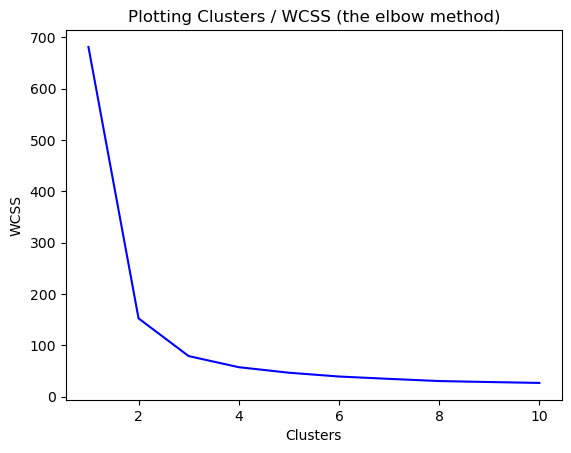

In [2]:
# plot the elbow curve
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

iris = load_iris()
X = iris.data

sns.set_palette(sns.color_palette(colors))

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)
    
plt.plot(range(1, 11), wcss)
plt.title('Plotting Clusters / WCSS (the elbow method)')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

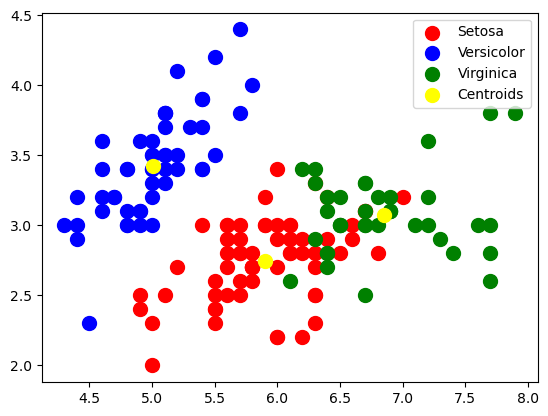

In [3]:
# kmeans for iris
km = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
predictions = km.fit_predict(X)

plt.scatter(X[predictions==0, 0], X[predictions==0, 1], s=100, c='red', label='Setosa')
plt.scatter(X[predictions==1, 0], X[predictions==1, 1], s=100, c='blue', label='Versicolor')
plt.scatter(X[predictions==2, 0], X[predictions==2, 1], s=100, c='green', label='Virginica')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=100, color='yellow', label='Centroids')
plt.legend();

What does X look like? What does X consist of?

## Hierarchical

In data mining and statistics, hierarchical clustering (also called hierarchical cluster analysis or HCA) is a method of cluster analysis which seeks to build a hierarchy of clusters. Strategies for hierarchical clustering ... Agglomerative: This is a "bottom-up" approach: each observation starts in its own cluster, and pairs of clusters are merged as one moves up the hierarchy.

### Agglomerative

* Bottom up

### Divisive

* Top down

### Dendogram

A dendrogram is a diagram representing a tree. In hierarchical clustering, it illustrates the arrangement of the clusters produced by the corresponding analyses.

https://en.wikipedia.org/wiki/Dendrogram

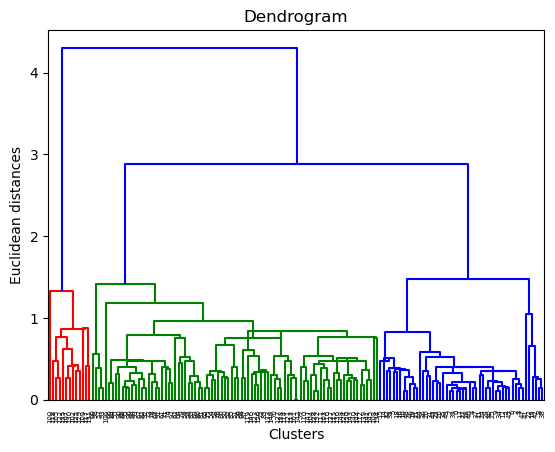

In [4]:
# dendograms
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
import scipy.cluster.hierarchy as sch

iris = load_iris()
X = iris.data

dendrogram = sch.dendrogram(sch.linkage(X, method='median'), color_threshold=2)
plt.title('Dendrogram')
plt.xlabel('Clusters')
plt.ylabel('Euclidean distances')
plt.show()

Two ways to determine number of clusters

* Find the longest vertical line and draw a horizontal line at the center
* Determine the threshold and draw a horizontal line through the middle

Count the number of lines above the threshold

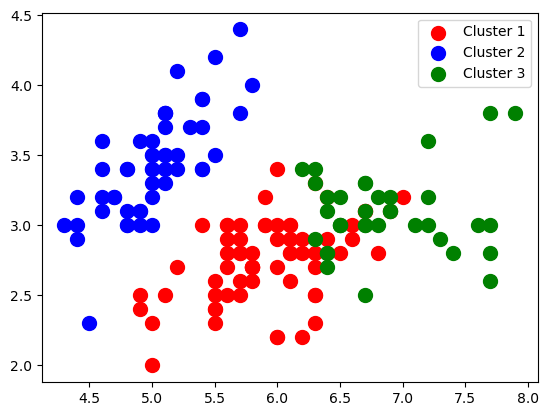

In [5]:
# agglomerative clustering 
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters = 3, affinity = 'euclidean', linkage = 'ward')
y = hc.fit_predict(X)

plt.scatter(X[y == 0, 0], X[y == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y == 1, 0], X[y == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y == 2, 0], X[y == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.legend()
plt.show()

## Mean Shift

## DBSCAN

https://www.analyticsvidhya.com/blog/2020/09/how-dbscan-clustering-works/

* Density-Based Spatial Clustering of Applications with Noise
* Identifies clusters in large spatial datasets by looking at the local density of the data points
* Robust to outliers
* Does not require initial cluster value
* Epsion: Radius of the circle to be created around each data point
* MinPoints: Minimum number of data points required inside that circle to be classified
* Noise: Data points not within epsilon radius
* Directly Density-Reachable: X is in y neighborhood; y is core point
* Density-Reachable: A chain of reachable points
* Density-Connected: Both X and y are reachable from another core point

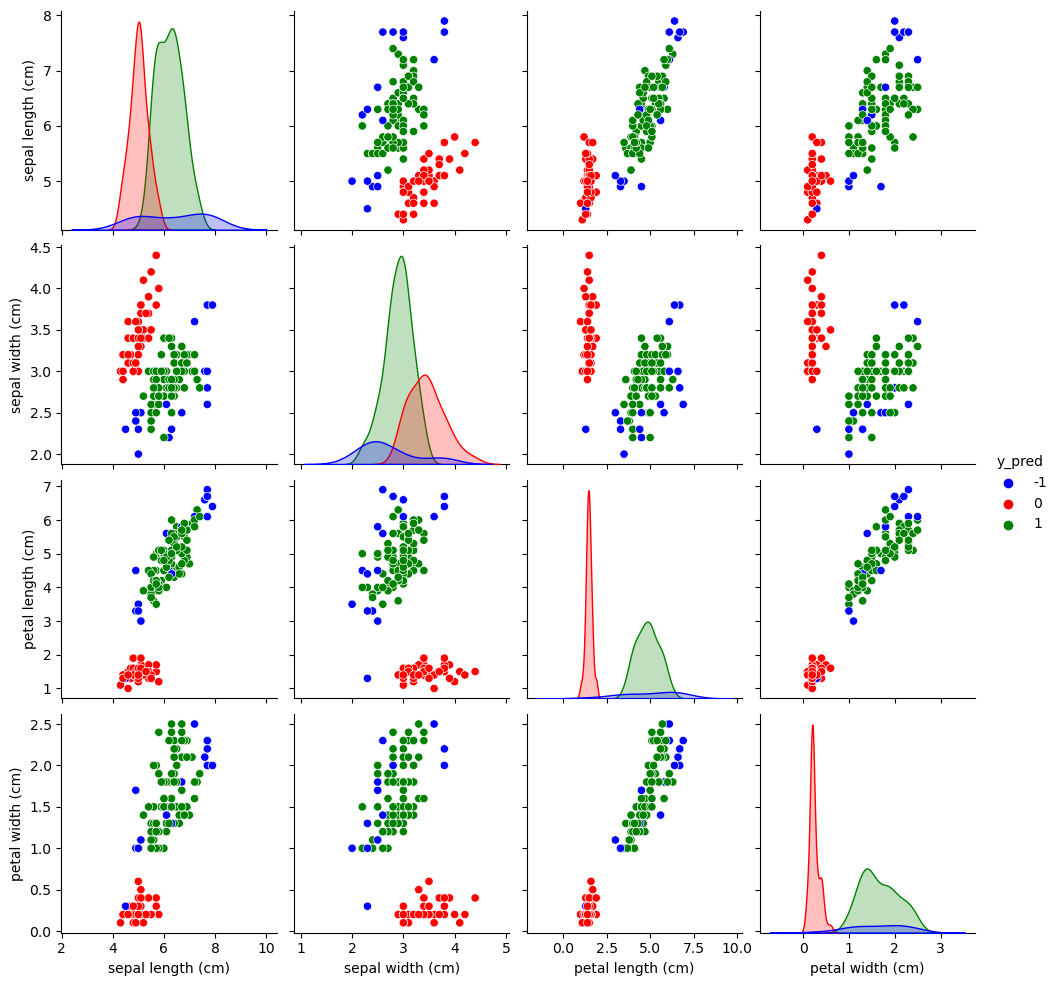

In [6]:
from sklearn.cluster import DBSCAN

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

dbscan = DBSCAN().fit(df)
y_pred = dbscan.fit_predict(df)

df['y_pred'] = y_pred

colors = ['blue', 'red', 'green']
sns.pairplot(df, hue='y_pred', palette=colors)
plt.show()

## Sihlouette

https://towardsdatascience.com/silhouette-coefficient-validating-clustering-techniques-e976bb81d10c

* 1: Means clusters are well apart from each other and clearly distinguished.
* 0: Means clusters are indifferent, or we can say that the distance between clusters is not significant.
* -1: Means clusters are assigned in the wrong way.
* Silhouette Score = $(b-a)/max(a,b)$
* where a = average intra-cluster distance: the average distance between each point within a cluster
* b = average inter-cluster distance: the average distance between clusters 

In [7]:
from sklearn.metrics import silhouette_score

labels = dbscan.labels_
print(set(labels))

silhouette_score(df, labels, metric='euclidean')

{0, 1, -1}


0.6079130430464743

## Silhouette Plot

https://www.baeldung.com/cs/silhouette-values-clustering

* X axis shows the silhouette values
* Height of each sihouette indicates the number of points in the corresponding cluster
* Red line shows the average sihouette value for all the clusters

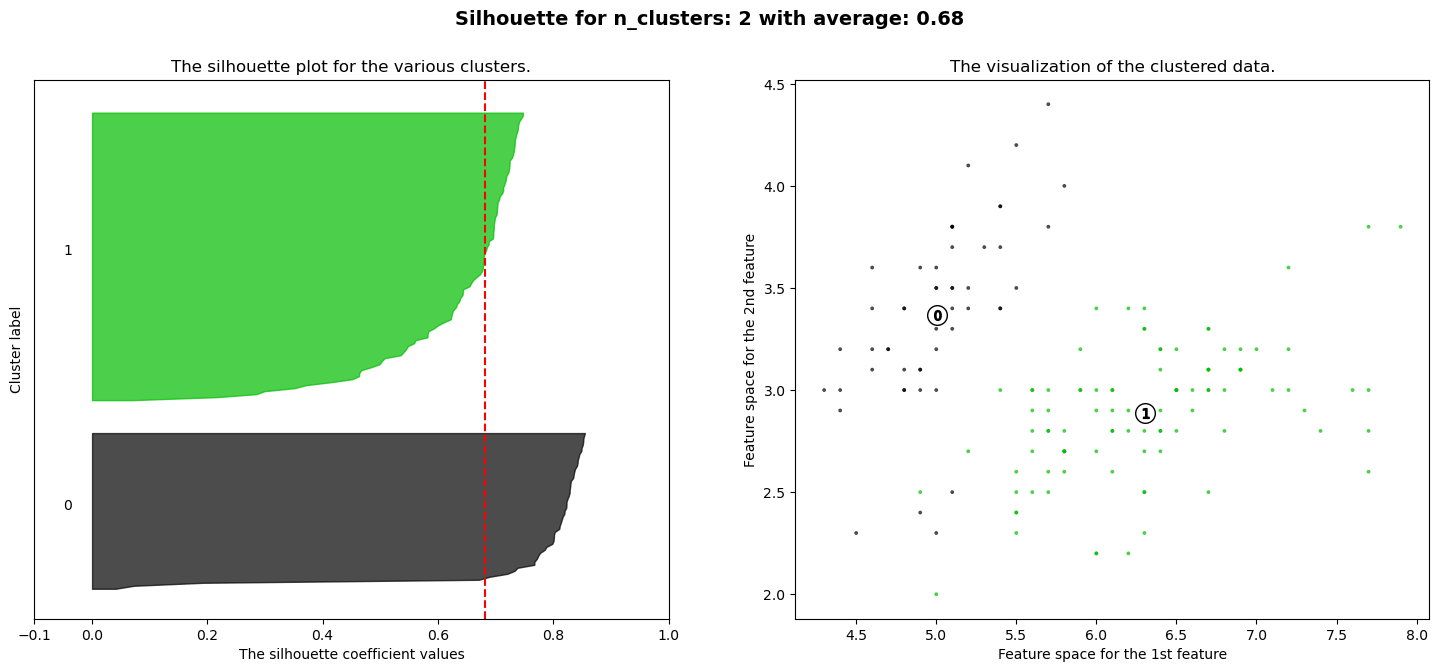

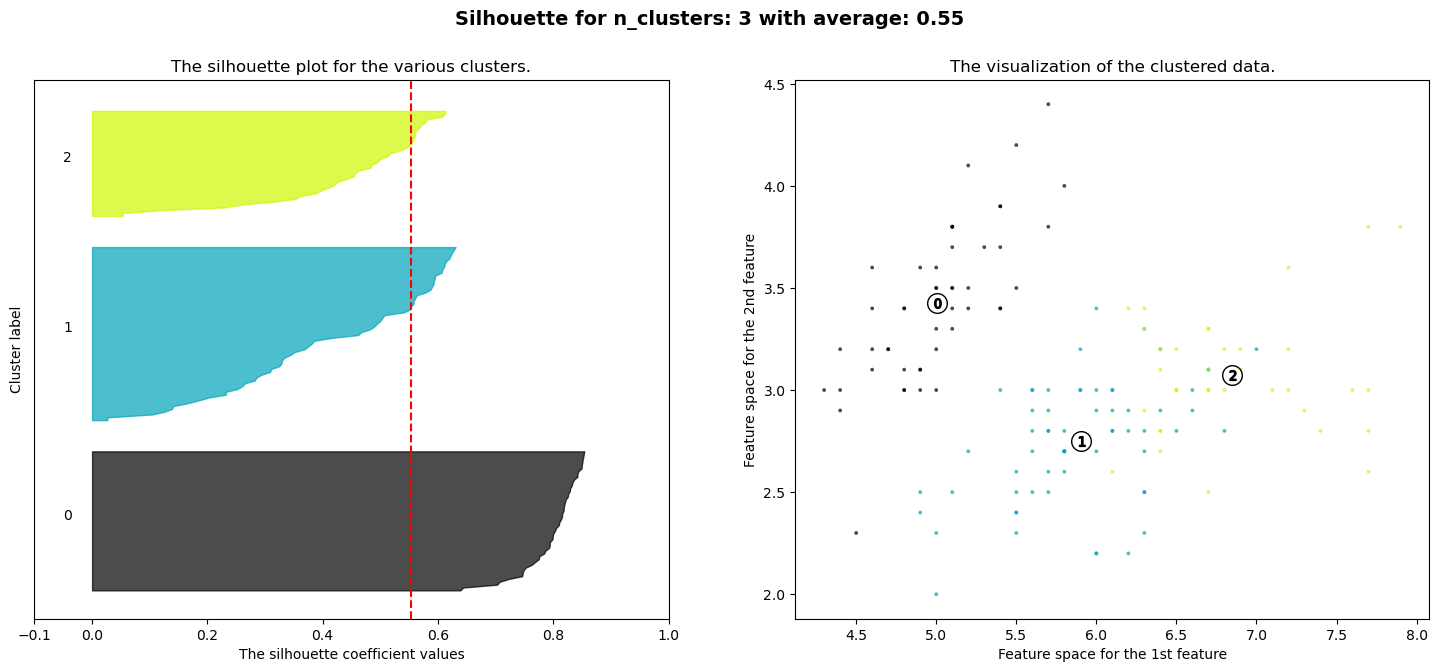

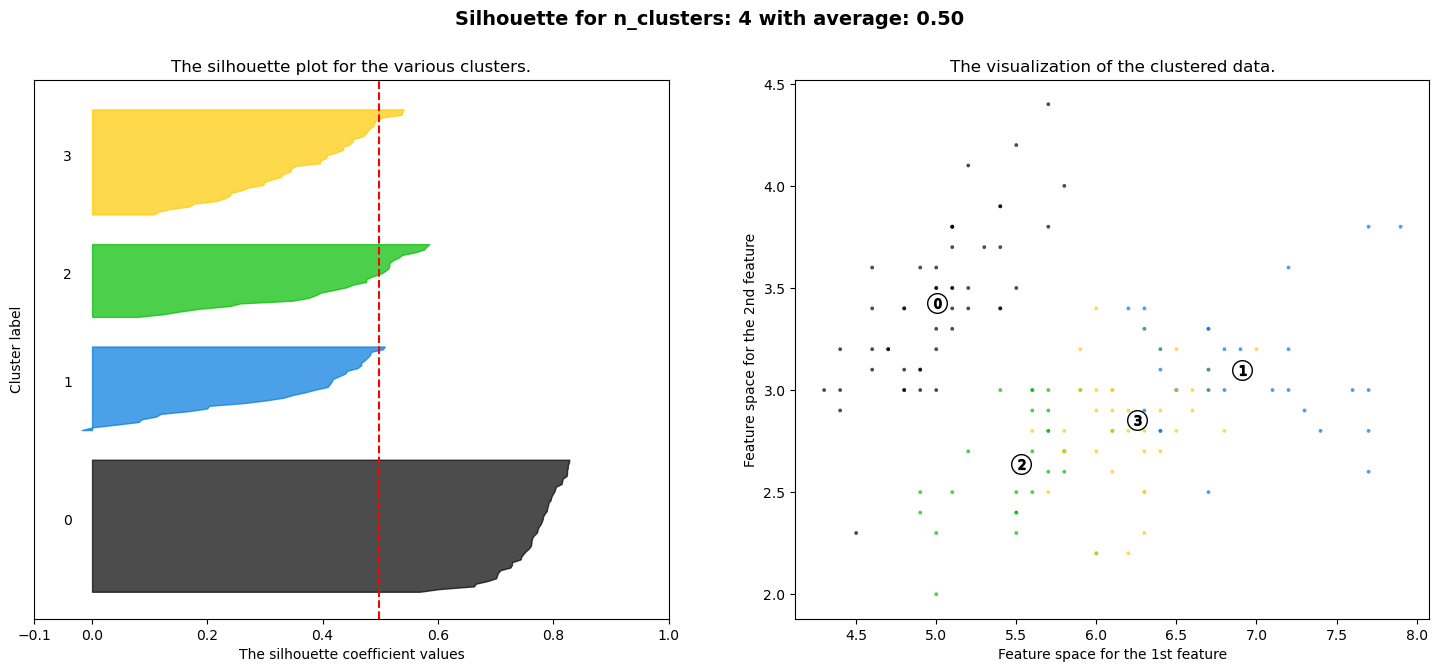

In [8]:
# https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

X = df.drop('y_pred', axis=1).to_numpy()

range_n_clusters = [2, 3, 4]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title('The silhouette plot for the various clusters.')
    ax1.set_xlabel('The silhouette coefficient values')
    ax1.set_ylabel('Cluster label')

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color='red', linestyle='--')

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k'
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker='o',
        c='white',
        alpha=1,
        s=200,
        edgecolor='k',
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')

    ax2.set_title('The visualization of the clustered data.')
    ax2.set_xlabel('Feature space for the 1st feature')
    ax2.set_ylabel('Feature space for the 2nd feature')

    plt.suptitle(
        f'Silhouette for n_clusters: {n_clusters} with average: {silhouette_avg:.2f}',
        fontsize=14,
        fontweight='bold',
    )

plt.show()

## Expectation-Maximization (EM) Clustering using Gaussian Mixture Models (GMM)

Normally distributed clusters?

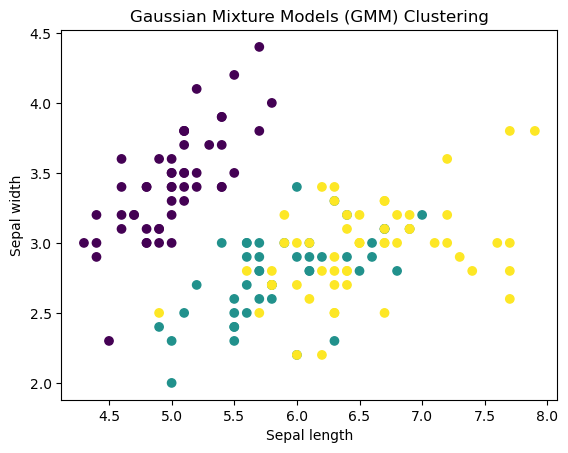

In [9]:
# https://soumenatta.medium.com/gaussian-mixture-models-gmm-clustering-in-python-d8d6ca2693f2   
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
# y = iris.target

gmm = GaussianMixture(n_components=3)
gmm.fit(X)

labels = gmm.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis') 
# X[:, 0] means rows first:last, columns first:last, before the value until, after before
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Gaussian Mixture Models (GMM) Clustering')
plt.show()